# 🛡️ Detección de Fraude en Seguros de Autos
## Metodología CRISP-DM — Machine Learning 1
**Universidad de La Sabana**  
Prof. Jesús Antonio Villarraga P.  

---
> **Alumno:** Martín Jerez Ramírez  
> **Problema:** Clasificación binaria — ¿Es una reclamación fraudulenta?  
> **Dataset:** `insurance_claims.csv` — 1,000 registros, 39 columnas  
> **Modelos requeridos:** Regresión Logística + Árbol de Decisión


---
## 📌 Fase 1: Comprensión del Problema (Business Understanding)

### 1.1 Contexto y motivación

El fraude en seguros de autos representa una pérdida significativa para las aseguradoras a nivel mundial. Según la *Insurance Research Council*, aproximadamente el 15–20% de las reclamaciones de seguros contienen algún tipo de irregularidad. Detectar estos casos de forma temprana permite:

- Reducir pérdidas económicas directas para la aseguradora.
- Mantener primas competitivas para clientes legítimos.
- Optimizar el proceso de investigación de siniestros.

### 1.2 Variable objetivo

La variable objetivo es **`fraud_reported`**, que toma dos valores:
- **Y (Yes):** La reclamación fue identificada como fraudulenta → clase de interés (positivo).
- **N (No):** La reclamación es legítima → clase negativa.

### 1.3 Implicaciones de errores de clasificación

| Tipo de error | Descripción | Impacto |
|---|---|---|
| **Falso Positivo (FP)** | Se clasifica como fraude una reclamación legítima | Daño reputacional, fricción con el cliente, demandas legales |
| **Falso Negativo (FN)** | Se aprueba un fraude real | Pérdida económica directa, incentivo para futuros fraudes |

> **Conclusión metodológica:** En detección de fraude, los **Falsos Negativos** tienen un costo mayor. Por ello, **el Recall de la clase fraude (Y)** es nuestra métrica principal. Un modelo que detecta todos los fraudes reales (aunque genere algunas alertas falsas) es preferible a uno que los deja pasar.


---
## 📦 Librerías y Configuración


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

# Estilo visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


---
## 🔍 Fase 2: Comprensión de los Datos (Data Understanding)


In [2]:
# Carga del dataset
df = pd.read_csv('insurance_claims.csv')
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head()


Dimensiones: 1000 filas × 40 columnas


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [3]:
# Tipos de variables y valores no nulos
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   str    
 4   policy_state                 1000 non-null   str    
 5   policy_csl                   1000 non-null   str    
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   str    
 11  insured_education_level      1000 non-null   str    
 12  insured_occupation           1000 non-null   str    
 13  insured_hobbies              1

### 2.1 Descripción del dataset

El conjunto de datos contiene **1,000 reclamaciones de seguros de autos** con las siguientes categorías de variables:

| Grupo | Variables | Tipo |
|---|---|---|
| Perfil del asegurado | `age`, `insured_sex`, `insured_education_level`, `insured_occupation`, `insured_hobbies`, `insured_relationship` | Mixto |
| Póliza | `months_as_customer`, `policy_state`, `policy_csl`, `policy_deductable`, `policy_annual_premium`, `umbrella_limit` | Mixto |
| Incidente | `incident_type`, `collision_type`, `incident_severity`, `incident_hour_of_the_day`, `number_of_vehicles_involved` | Mixto |
| Testigos y autoridades | `witnesses`, `authorities_contacted`, `property_damage`, `police_report_available` | Mixto |
| Reclamación financiera | `total_claim_amount`, `injury_claim`, `property_claim`, `vehicle_claim` | Numérico |
| Vehículo | `auto_make`, `auto_model`, `auto_year` | Mixto |
| **Variable objetivo** | `fraud_reported` | Binario (Y/N) |

Variables **excluidas por diseño** (no aportan información predictiva):
- `policy_number`, `insured_zip`, `incident_location`, `incident_date`, `policy_bind_date`, `_c39` (columna vacía).


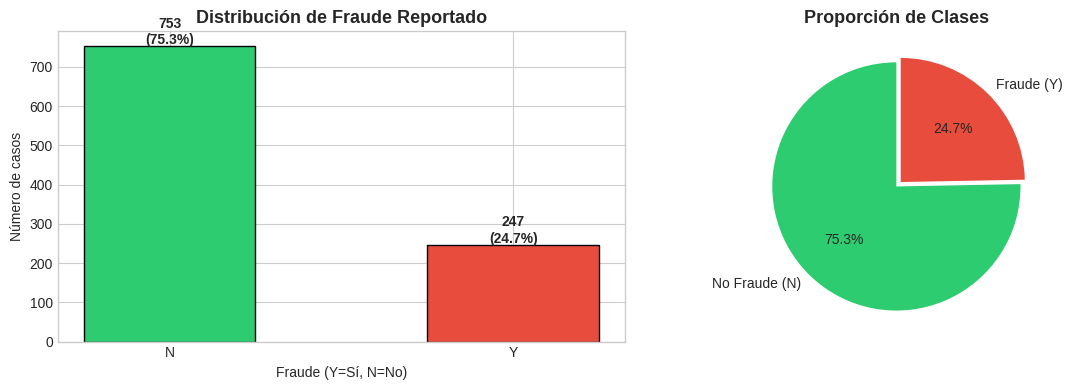


📊 Clases: Fraude (Y)=247 (24.7%) | No Fraude (N)=753 (75.3%)
⚠️  Existe desbalance moderado: ~1 fraude por cada 3 casos legítimos.


In [4]:
# Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
counts = df['fraud_reported'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
axes[0].set_title('Distribución de Fraude Reportado', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Fraude (Y=Sí, N=No)')
axes[0].set_ylabel('Número de casos')
for i, (k, v) in enumerate(counts.items()):
    axes[0].text(i, v + 5, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Pie
axes[1].pie(counts.values, labels=['No Fraude (N)', 'Fraude (Y)'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, explode=[0, 0.05])
axes[1].set_title('Proporción de Clases', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('distribucion_objetivo.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\n📊 Clases: Fraude (Y)={counts['Y']} ({counts['Y']/len(df)*100:.1f}%) | No Fraude (N)={counts['N']} ({counts['N']/len(df)*100:.1f}%)")
print("⚠️  Existe desbalance moderado: ~1 fraude por cada 3 casos legítimos.")


In [5]:
# Estadísticas descriptivas — variables numéricas
num_cols = ['months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium',
            'umbrella_limit', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day',
            'number_of_vehicles_involved', 'bodily_injuries', 'witnesses',
            'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year']

df[num_cols].describe().round(2)


,months_as_customer,age,policy_deductable,policy_annual_premium,umbrella_limit,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year
count,1000.00,1000.00,1000.00,1000.00,1000.0,1000.00,1000.0,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,203.95,38.95,1136.00,1256.41,1101000.0,25126.10,-26793.7,11.64,1.84,0.99,1.49,52761.94,7433.42,7399.57,37928.95,2005.10
std,115.11,9.14,611.86,244.17,2297406.6,27872.19,28104.1,6.95,1.02,0.82,1.11,26401.53,4880.95,4824.73,18886.25,6.02
min,0.00,19.00,500.00,433.33,-1000000.0,0.00,-111100.0,0.00,1.00,0.00,0.00,100.00,0.00,0.00,70.00,1995.00
25%,115.75,32.00,500.00,1089.61,0.0,0.00,-51500.0,6.00,1.00,0.00,1.00,41812.50,4295.00,4445.00,30292.50,2000.00
50%,199.50,38.00,1000.00,1257.20,0.0,0.00,-23250.0,12.00,1.00,1.00,1.00,58055.00,6775.00,6750.00,42100.00,2005.00
75%,276.25,44.00,2000.00,1415.70,0.0,51025.00,0.0,17.00,3.00,2.00,2.00,70592.50,11305.00,10885.00,50822.50,2010.00
max,479.00,64.00,2000.00,2047.59,10000000.0,100500.00,0.0,23.00,4.00,2.00,3.00,114920.00,21450.00,23670.00,79560.00,2015.00


In [6]:
# Análisis de valores nulos y problemáticos
print("=== VALORES NULOS POR COLUMNA ===")
nulls = df.isnull().sum()
print(nulls[nulls > 0])

print("\n=== VALORES '?' EN COLUMNAS CATEGÓRICAS ===")
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    q_count = (df[col] == '?').sum()
    if q_count > 0:
        print(f"  {col}: {q_count} registros con '?'")


=== VALORES NULOS POR COLUMNA ===
authorities_contacted      91
_c39                     1000
dtype: int64

=== VALORES '?' EN COLUMNAS CATEGÓRICAS ===
  collision_type: 178 registros con '?'
  property_damage: 360 registros con '?'
  police_report_available: 343 registros con '?'


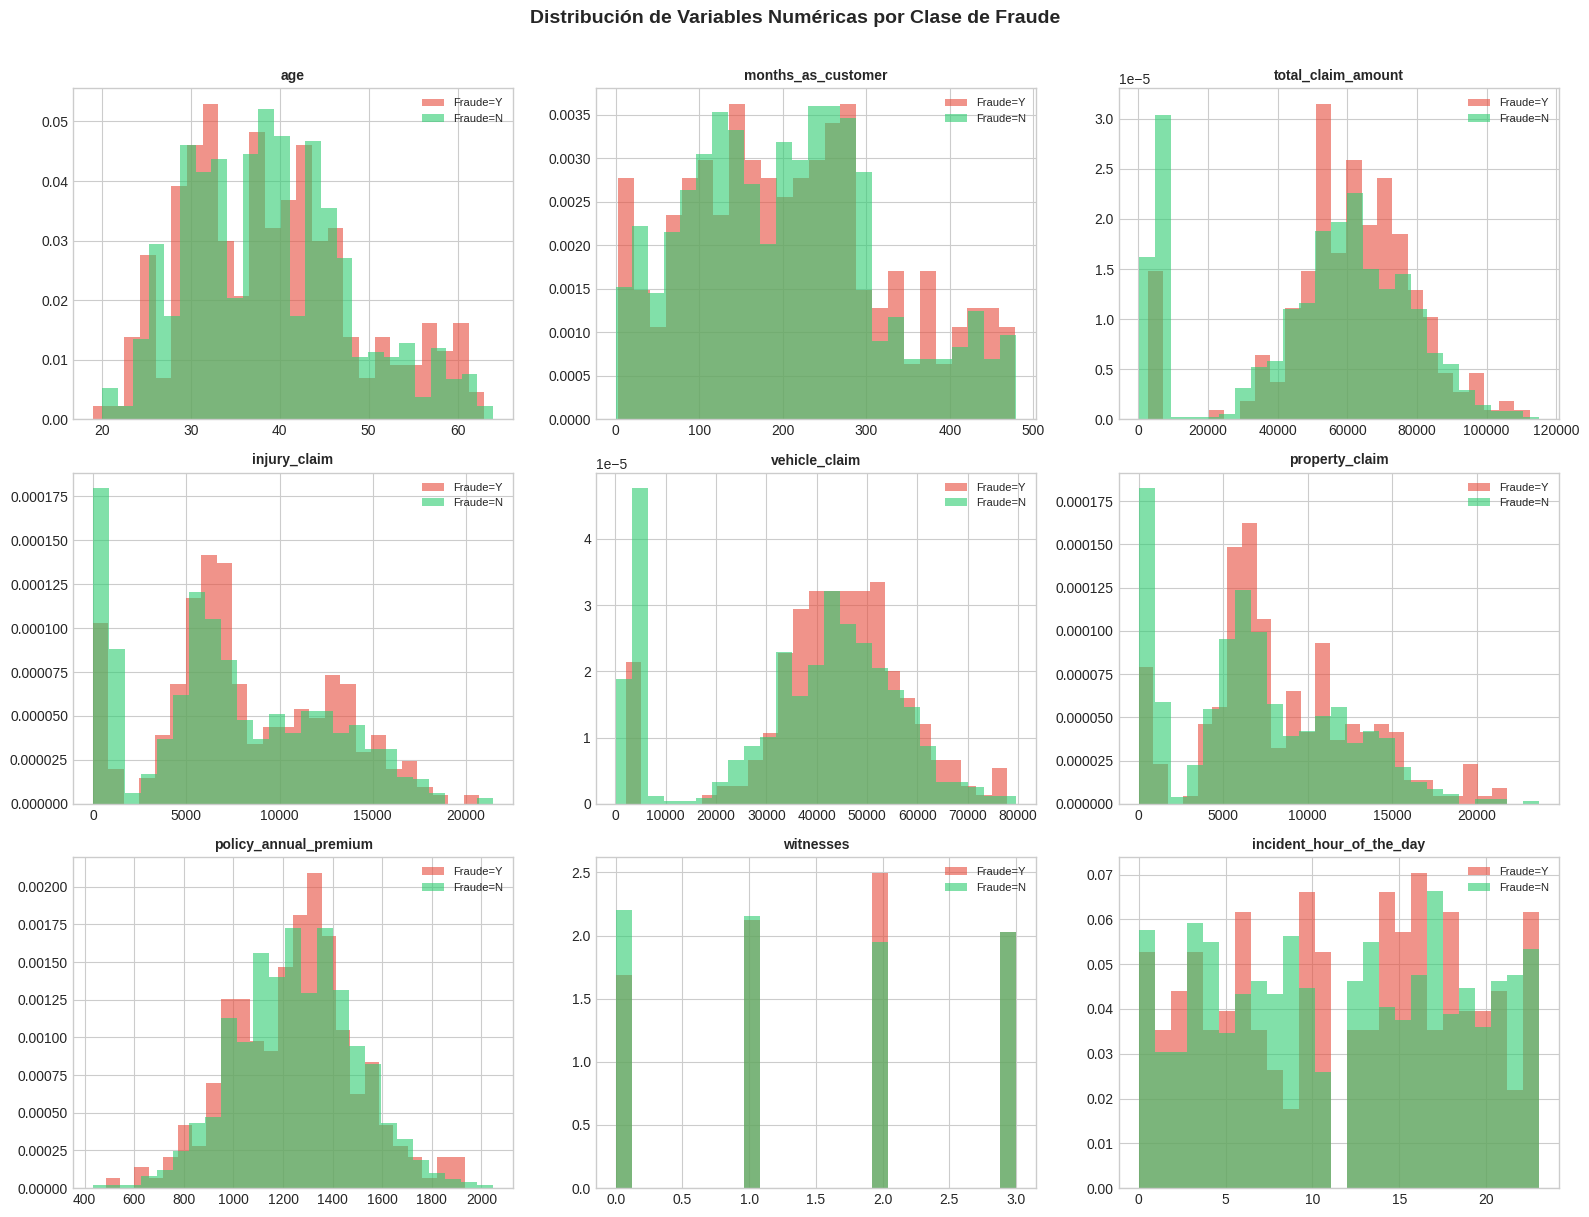

In [7]:
# Distribuciones variables numéricas vs fraude
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

plot_vars = ['age', 'months_as_customer', 'total_claim_amount',
             'injury_claim', 'vehicle_claim', 'property_claim',
             'policy_annual_premium', 'witnesses', 'incident_hour_of_the_day']

for i, var in enumerate(plot_vars):
    for label, color in [('Y', '#e74c3c'), ('N', '#2ecc71')]:
        axes[i].hist(df[df['fraud_reported'] == label][var].dropna(),
                     alpha=0.6, bins=25, color=color, label=f'Fraude={label}', density=True)
    axes[i].set_title(var, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución de Variables Numéricas por Clase de Fraude', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('distribuciones_numericas.png', dpi=120, bbox_inches='tight')
plt.show()


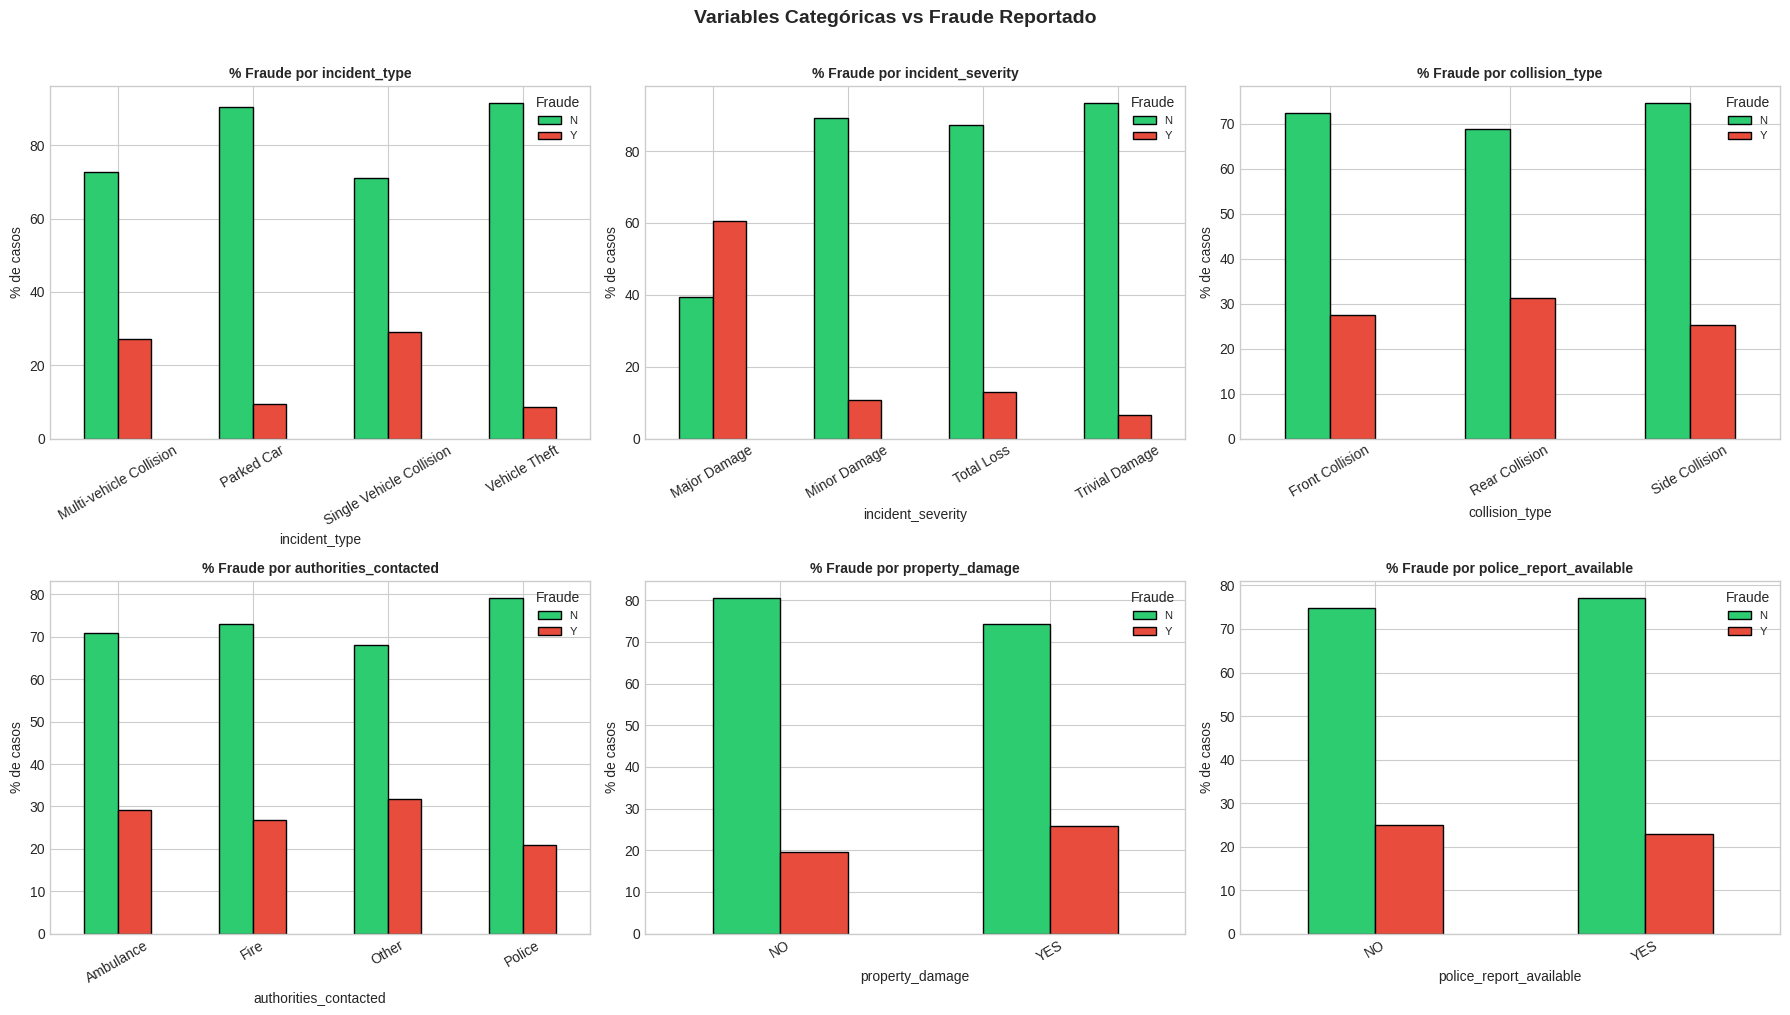

In [8]:
# Variables categóricas clave vs fraude
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

cat_plot_vars = ['incident_type', 'incident_severity', 'collision_type',
                 'authorities_contacted', 'property_damage', 'police_report_available']

for i, var in enumerate(cat_plot_vars):
    df_clean = df[df[var] != '?'].copy()
    ct = pd.crosstab(df_clean[var], df_clean['fraud_reported'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'], edgecolor='black', rot=30)
    axes[i].set_title(f'% Fraude por {var}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('% de casos')
    axes[i].legend(title='Fraude', fontsize=8)

plt.suptitle('Variables Categóricas vs Fraude Reportado', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('categoricas_vs_fraude.png', dpi=120, bbox_inches='tight')
plt.show()


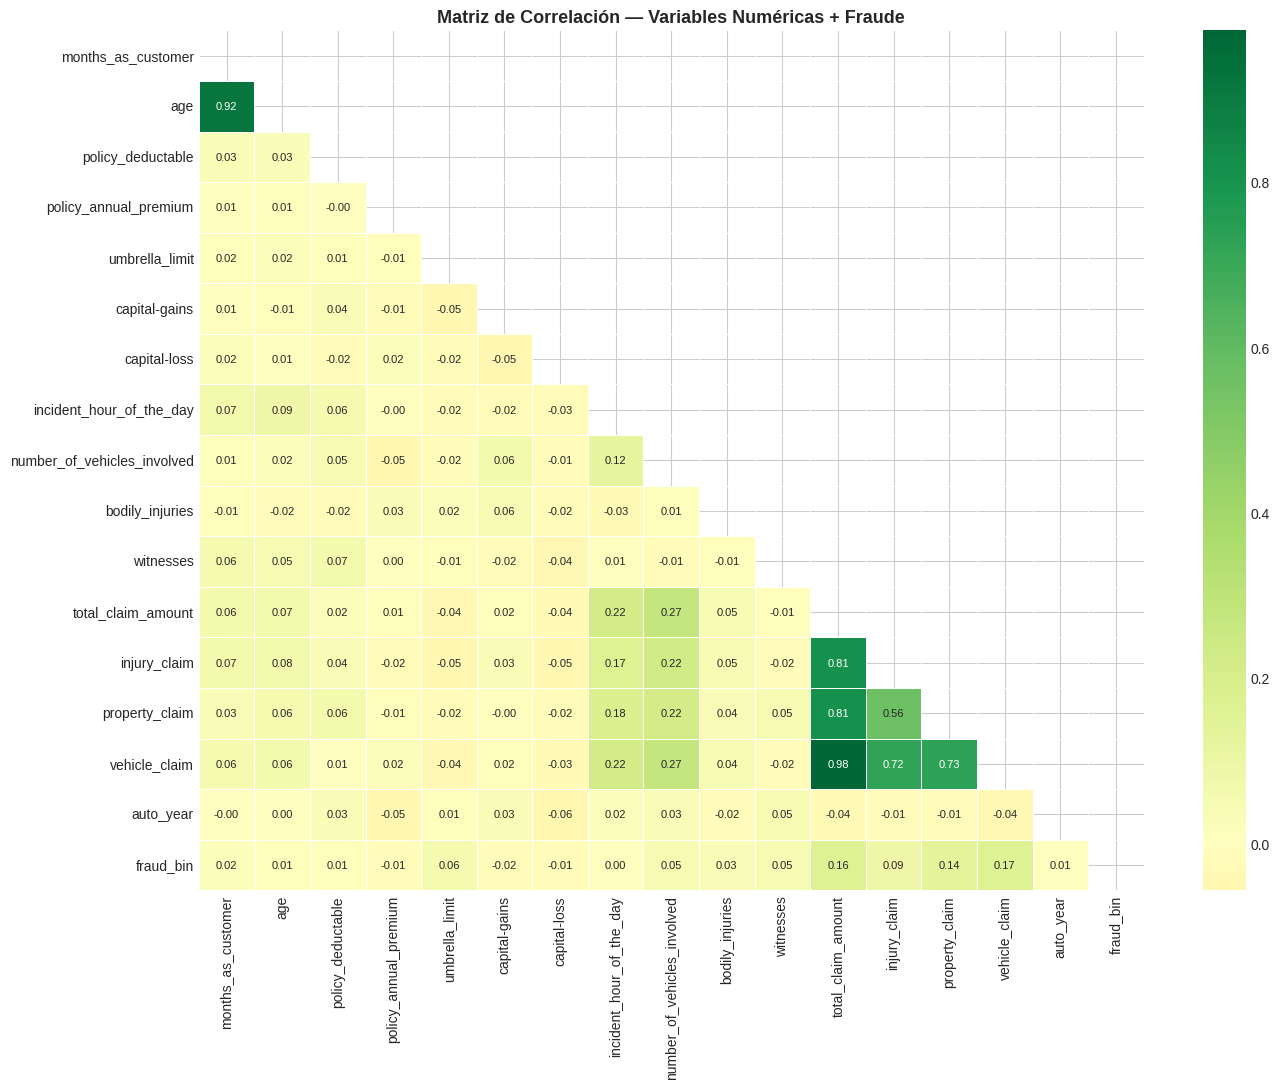


🔍 Correlaciones con la variable fraude (|r| > 0.05):
vehicle_claim                  0.170
total_claim_amount             0.164
property_claim                 0.138
injury_claim                   0.091
umbrella_limit                 0.059
number_of_vehicles_involved    0.052
Name: fraud_bin, dtype: float64


In [9]:
# Correlación entre variables numéricas
df_corr = df[num_cols].copy()
df_corr['fraud_bin'] = (df['fraud_reported'] == 'Y').astype(int)

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(df_corr.corr(), mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Matriz de Correlación — Variables Numéricas + Fraude', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlacion.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n🔍 Correlaciones con la variable fraude (|r| > 0.05):")
corr_fraud = df_corr.corr()['fraud_bin'].drop('fraud_bin').abs().sort_values(ascending=False)
print(corr_fraud[corr_fraud > 0.05].round(3))


---
## ⚙️ Fase 3: Preparación de los Datos (Data Preparation)

### 3.1 Decisiones de limpieza

| Variable | Acción | Justificación |
|---|---|---|
| `_c39` | **Eliminar** | Columna completamente vacía (100% NaN) |
| `policy_number` | **Eliminar** | Identificador único sin valor predictivo |
| `insured_zip` | **Eliminar** | Alta cardinalidad, no aporta sin geocodificación |
| `incident_location` | **Eliminar** | Texto libre, alta cardinalidad |
| `incident_date`, `policy_bind_date` | **Eliminar** | Fechas — requieren ingeniería de features no incluida en el alcance |
| `collision_type`, `property_damage`, `police_report_available` | **Imputar '?'** | Reemplazar con moda (valor más frecuente) |
| `authorities_contacted` | **Imputar NaN** | Reemplazar con moda |
| `insured_hobbies` | **Eliminar** | 20 categorías únicas con baja señal predictiva |
| `auto_model`, `auto_make` | **Eliminar** | Alta cardinalidad, `auto_year` captura la información relevante |
| `incident_city`, `incident_state` | **Eliminar** | Alta cardinalidad geográfica |


In [10]:
# ── 3.1 Copia de trabajo y eliminación de columnas irrelevantes ──
df_prep = df.copy()

drop_cols = [
    '_c39',               # columna vacía
    'policy_number',      # ID
    'insured_zip',        # alta cardinalidad
    'incident_location',  # texto libre
    'incident_date',      # fecha sin descomposición
    'policy_bind_date',   # fecha sin descomposición
    'insured_hobbies',    # 20 categorías, baja señal
    'auto_model',         # alta cardinalidad
    'auto_make',          # alta cardinalidad (auto_year captura el efecto)
    'incident_city',      # alta cardinalidad geográfica
    'incident_state',     # redundante con policy_state
]

df_prep.drop(columns=drop_cols, inplace=True)
print(f"Columnas restantes: {df_prep.shape[1]}")
print(df_prep.columns.tolist())


Columnas restantes: 29
['months_as_customer', 'age', 'policy_state', 'policy_csl', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_relationship', 'capital-gains', 'capital-loss', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'property_damage', 'bodily_injuries', 'witnesses', 'police_report_available', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year', 'fraud_reported']


In [11]:
# ── 3.2 Tratamiento de valores problemáticos ──

# '?' → NaN para facilitar imputación
df_prep.replace('?', np.nan, inplace=True)

# Imputación con la moda (variables categóricas)
for col in ['collision_type', 'property_damage', 'police_report_available', 'authorities_contacted']:
    moda = df_prep[col].mode()[0]
    n_imp = df_prep[col].isna().sum()
    df_prep[col].fillna(moda, inplace=True)
    print(f"  {col}: {n_imp} valores imputados con moda='{moda}'")

print(f"\nValores nulos restantes: {df_prep.isnull().sum().sum()}")


  collision_type: 178 valores imputados con moda='Rear Collision'
  property_damage: 360 valores imputados con moda='NO'
  police_report_available: 343 valores imputados con moda='NO'
  authorities_contacted: 91 valores imputados con moda='Police'

Valores nulos restantes: 972


In [12]:
# ── 3.3 Codificación de la variable objetivo ──
df_prep['fraud_reported'] = (df_prep['fraud_reported'] == 'Y').astype(int)
print("Distribución objetivo codificado:")
print(df_prep['fraud_reported'].value_counts())


Distribución objetivo codificado:
fraud_reported
0    753
1    247
Name: count, dtype: int64


In [13]:
# ── 3.4 Codificación de variables categóricas (One-Hot Encoding) ──
cat_features = [
    'policy_state', 'policy_csl', 'insured_sex', 'insured_education_level',
    'insured_occupation', 'insured_relationship', 'incident_type',
    'collision_type', 'incident_severity', 'authorities_contacted',
    'property_damage', 'police_report_available'
]

df_encoded = pd.get_dummies(df_prep, columns=cat_features, drop_first=True)

# Convertir booleanos a int
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f"Dimensiones tras OHE: {df_encoded.shape}")
print(f"Total de features: {df_encoded.shape[1] - 1} (excluyendo target)")


Dimensiones tras OHE: (1000, 59)
Total de features: 58 (excluyendo target)


In [14]:
# ── 3.5 Separación Features / Target ──
X = df_encoded.drop('fraud_reported', axis=1)
y = df_encoded['fraud_reported']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Balance de clases — Fraude(1): {y.sum()} | No Fraude(0): {(y==0).sum()}")


X shape: (1000, 58)
y shape: (1000,)
Balance de clases — Fraude(1): 247 | No Fraude(0): 753


In [15]:
# ── 3.6 Partición Entrenamiento / Prueba (Estratificada) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train: {X_train.shape[0]} registros | Fraude: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Test:  {X_test.shape[0]} registros  | Fraude: {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print("✅ Partición estratificada garantiza proporción de fraudes en ambos conjuntos.")


Train: 800 registros | Fraude: 198 (24.8%)
Test:  200 registros  | Fraude: 49 (24.5%)
✅ Partición estratificada garantiza proporción de fraudes en ambos conjuntos.


In [16]:
# ── 3.7 Escalado de variables numéricas ──
# Necesario para Regresión Logística (sensible a magnitudes)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Variables escaladas con StandardScaler (fit solo sobre train — evita data leakage)")


✅ Variables escaladas con StandardScaler (fit solo sobre train — evita data leakage)


---
## 🤖 Fase 4: Modelado (Modeling)

### Estrategia general

Dado el desbalance de clases (~75/25) y el tamaño moderado del dataset (1,000 registros), se aplican las siguientes estrategias:

1. **`class_weight='balanced'`**: Ambos modelos ajustan los pesos internamente para compensar el desbalance, priorizando la clase minoritaria (fraude).  
2. **Ajuste del umbral de decisión**: Se explorará el umbral óptimo para maximizar el Recall de fraude.  
3. **Validación cruzada estratificada (5-fold)**: Para estimaciones robustas en un dataset pequeño.


### 4.1 Modelo 1: Regresión Logística


In [17]:
# ── REGRESIÓN LOGÍSTICA ──
lr = LogisticRegression(
    class_weight='balanced',  # compensa desbalance
    max_iter=1000,
    random_state=SEED,
    solver='lbfgs',
    C=0.1  # regularización L2 moderada para dataset pequeño
)
lr.fit(X_train_scaled, y_train)

# Predicciones con umbral estándar (0.5)
y_pred_lr     = lr.predict(X_test_scaled)
y_proba_lr    = lr.predict_proba(X_test_scaled)[:, 1]

print("=== Regresión Logística — Umbral 0.5 ===")
print(classification_report(y_test, y_pred_lr, target_names=['No Fraude', 'Fraude']))


=== Regresión Logística — Umbral 0.5 ===
              precision    recall  f1-score   support

   No Fraude       0.92      0.86      0.89       151
      Fraude       0.64      0.76      0.69        49

    accuracy                           0.83       200
   macro avg       0.78      0.81      0.79       200
weighted avg       0.85      0.83      0.84       200



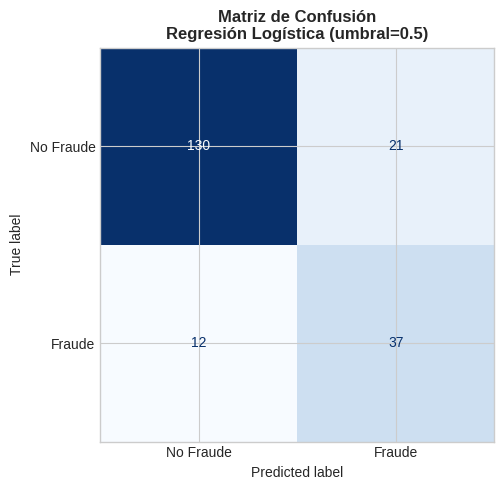

In [18]:
# Matriz de confusión — Regresión Logística
fig, ax = plt.subplots(figsize=(6, 5))
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(cm_lr, display_labels=['No Fraude', 'Fraude'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión\nRegresión Logística (umbral=0.5)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_lr.png', dpi=120, bbox_inches='tight')
plt.show()


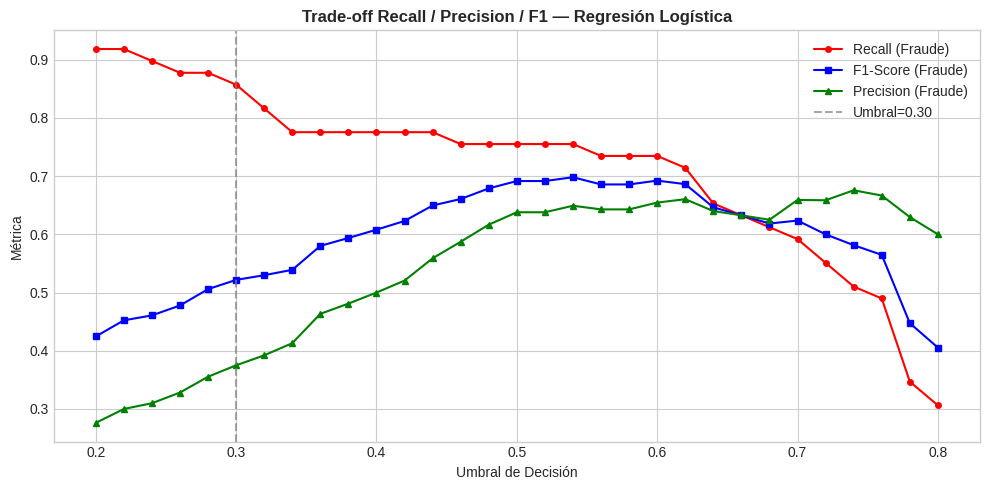

Umbral óptimo por F1: 0.54
  Recall:    0.755
  F1-Score:  0.698
  Precision: 0.649


In [19]:
# Optimización del umbral para maximizar Recall de fraude
from sklearn.metrics import recall_score, f1_score, precision_score

thresholds = np.arange(0.20, 0.81, 0.02)
recalls, f1s, precisions = [], [], []

for t in thresholds:
    y_pred_t = (y_proba_lr >= t).astype(int)
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, recalls, 'r-o', markersize=4, label='Recall (Fraude)')
ax.plot(thresholds, f1s, 'b-s', markersize=4, label='F1-Score (Fraude)')
ax.plot(thresholds, precisions, 'g-^', markersize=4, label='Precision (Fraude)')
ax.axvline(x=0.3, color='gray', linestyle='--', alpha=0.7, label='Umbral=0.30')
ax.set_xlabel('Umbral de Decisión')
ax.set_ylabel('Métrica')
ax.set_title('Trade-off Recall / Precision / F1 — Regresión Logística', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('threshold_lr.png', dpi=120, bbox_inches='tight')
plt.show()

# Umbral óptimo por F1
best_idx = np.argmax(f1s)
print(f"Umbral óptimo por F1: {thresholds[best_idx]:.2f}")
print(f"  Recall:    {recalls[best_idx]:.3f}")
print(f"  F1-Score:  {f1s[best_idx]:.3f}")
print(f"  Precision: {precisions[best_idx]:.3f}")


=== Regresión Logística — Umbral Optimizado (0.3) ===
              precision    recall  f1-score   support

   No Fraude       0.92      0.54      0.68       151
      Fraude       0.38      0.86      0.52        49

    accuracy                           0.61       200
   macro avg       0.65      0.70      0.60       200
weighted avg       0.79      0.61      0.64       200



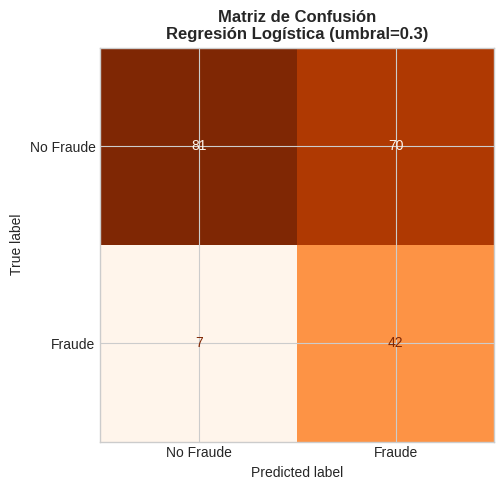

In [20]:
# Predicciones con umbral optimizado
BEST_THR_LR = 0.30  # umbral seleccionado balanceando recall y F1
y_pred_lr_opt = (y_proba_lr >= BEST_THR_LR).astype(int)

print(f"=== Regresión Logística — Umbral Optimizado ({BEST_THR_LR}) ===")
print(classification_report(y_test, y_pred_lr_opt, target_names=['No Fraude', 'Fraude']))

# Matriz de confusión actualizada
fig, ax = plt.subplots(figsize=(6, 5))
cm_lr_opt = confusion_matrix(y_test, y_pred_lr_opt)
disp = ConfusionMatrixDisplay(cm_lr_opt, display_labels=['No Fraude', 'Fraude'])
disp.plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title(f'Matriz de Confusión\nRegresión Logística (umbral={BEST_THR_LR})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_lr_opt.png', dpi=120, bbox_inches='tight')
plt.show()


In [21]:
# Validación cruzada — Regresión Logística
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results_lr = cross_validate(
    lr, X_train_scaled, y_train, cv=cv,
    scoring=['recall', 'f1', 'precision', 'roc_auc'],
    return_train_score=True
)

print("=== Validación Cruzada 5-Fold — Regresión Logística ===")
for metric in ['recall', 'f1', 'precision', 'roc_auc']:
    val_scores = cv_results_lr[f'test_{metric}']
    print(f"  {metric:12s}: {val_scores.mean():.3f} ± {val_scores.std():.3f}")


=== Validación Cruzada 5-Fold — Regresión Logística ===
  recall      : 0.672 ± 0.069
  f1          : 0.567 ± 0.067
  precision   : 0.493 ± 0.072
  roc_auc     : 0.733 ± 0.036


### 4.2 Modelo 2: Árbol de Decisión


In [22]:
# ── ÁRBOL DE DECISIÓN ──
dt = DecisionTreeClassifier(
    class_weight='balanced',     # compensa desbalance
    random_state=SEED,
    max_depth=5,                 # limitar profundidad para controlar sobreajuste
    min_samples_split=20,        # mínimo de muestras para dividir
    min_samples_leaf=10,         # mínimo de muestras en hoja
    criterion='gini'
)
dt.fit(X_train, y_train)

y_pred_dt  = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

print("=== Árbol de Decisión — Umbral 0.5 ===")
print(classification_report(y_test, y_pred_dt, target_names=['No Fraude', 'Fraude']))


=== Árbol de Decisión — Umbral 0.5 ===
              precision    recall  f1-score   support

   No Fraude       0.91      0.72      0.80       151
      Fraude       0.47      0.78      0.59        49

    accuracy                           0.73       200
   macro avg       0.69      0.75      0.70       200
weighted avg       0.80      0.73      0.75       200



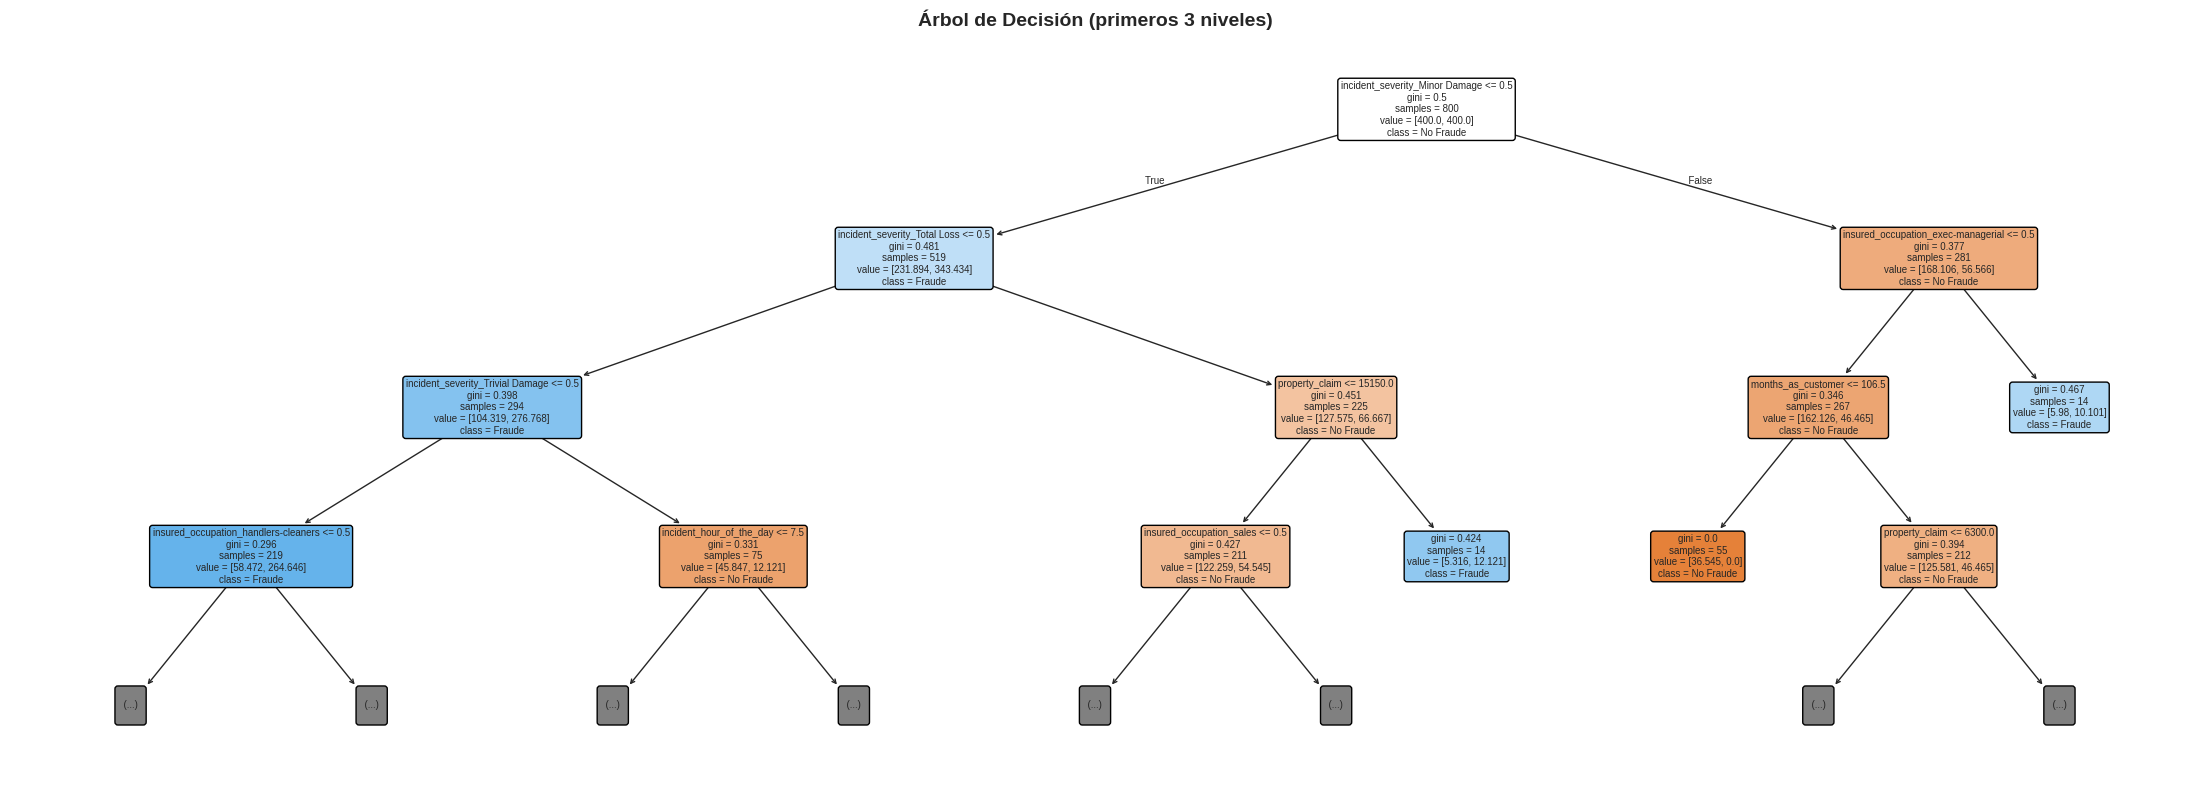

In [23]:
# Visualización del árbol (profundidad 3 para legibilidad)
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt, ax=ax,
    feature_names=X.columns,
    class_names=['No Fraude', 'Fraude'],
    filled=True, rounded=True,
    max_depth=3, fontsize=7,
    impurity=True, proportion=False
)
ax.set_title('Árbol de Decisión (primeros 3 niveles)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('arbol_decision.png', dpi=100, bbox_inches='tight')
plt.show()


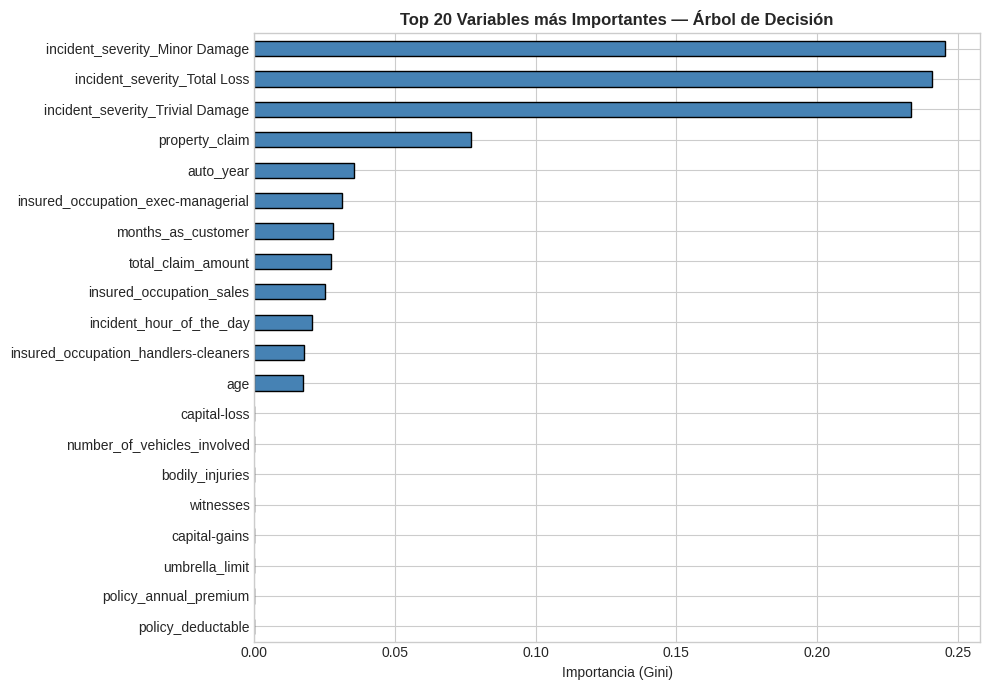

In [24]:
# Importancia de variables — Árbol de Decisión
feat_imp = pd.Series(dt.feature_importances_, index=X.columns)
feat_imp_top = feat_imp.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 7))
feat_imp_top.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Top 20 Variables más Importantes — Árbol de Decisión', fontsize=12, fontweight='bold')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.savefig('importancia_variables.png', dpi=120, bbox_inches='tight')
plt.show()


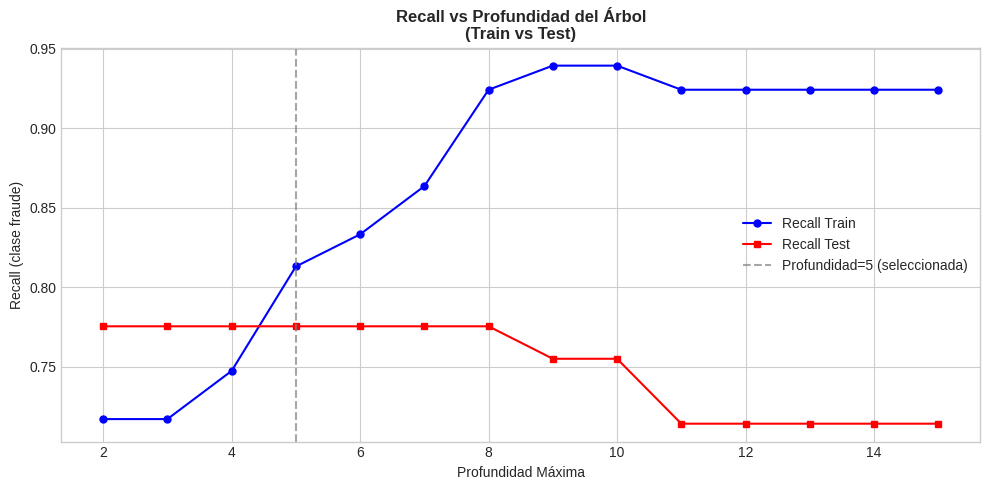

In [25]:
# Optimización de profundidad del árbol (evitar sobreajuste)
train_recalls, test_recalls = [], []
depths = range(2, 16)

for d in depths:
    dt_temp = DecisionTreeClassifier(
        max_depth=d, class_weight='balanced',
        min_samples_split=20, min_samples_leaf=10,
        random_state=SEED
    )
    dt_temp.fit(X_train, y_train)
    train_recalls.append(recall_score(y_train, dt_temp.predict(X_train)))
    test_recalls.append(recall_score(y_test, dt_temp.predict(X_test)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_recalls, 'b-o', markersize=5, label='Recall Train')
ax.plot(depths, test_recalls, 'r-s', markersize=5, label='Recall Test')
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.7, label='Profundidad=5 (seleccionada)')
ax.set_xlabel('Profundidad Máxima')
ax.set_ylabel('Recall (clase fraude)')
ax.set_title('Recall vs Profundidad del Árbol\n(Train vs Test)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('depth_tuning.png', dpi=120, bbox_inches='tight')
plt.show()


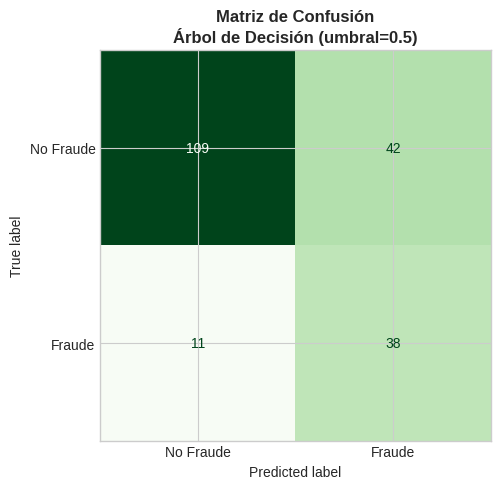

In [26]:
# Matriz de confusión — Árbol de Decisión
fig, ax = plt.subplots(figsize=(6, 5))
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(cm_dt, display_labels=['No Fraude', 'Fraude'])
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Matriz de Confusión\nÁrbol de Decisión (umbral=0.5)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_dt.png', dpi=120, bbox_inches='tight')
plt.show()


In [27]:
# Validación cruzada — Árbol de Decisión
cv_results_dt = cross_validate(
    dt, X_train, y_train, cv=cv,
    scoring=['recall', 'f1', 'precision', 'roc_auc'],
    return_train_score=True
)

print("=== Validación Cruzada 5-Fold — Árbol de Decisión ===")
for metric in ['recall', 'f1', 'precision', 'roc_auc']:
    val_scores = cv_results_dt[f'test_{metric}']
    print(f"  {metric:12s}: {val_scores.mean():.3f} ± {val_scores.std():.3f}")


=== Validación Cruzada 5-Fold — Árbol de Decisión ===
  recall      : 0.698 ± 0.070
  f1          : 0.523 ± 0.073
  precision   : 0.423 ± 0.076
  roc_auc     : 0.734 ± 0.056


---
## 📊 Fase 5: Evaluación Comparativa (Evaluation)


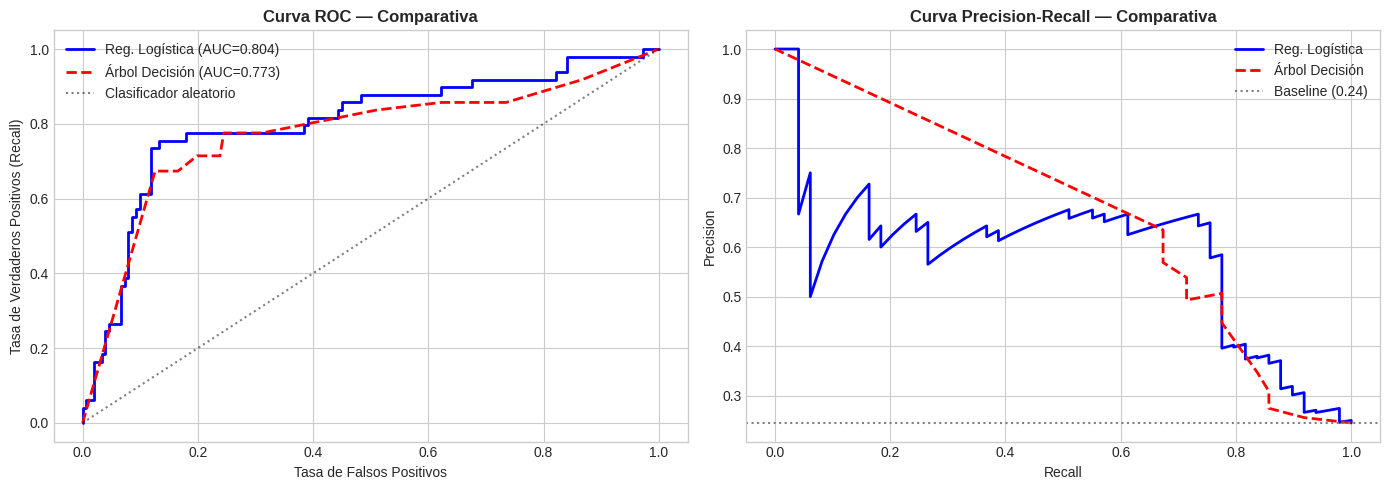

In [28]:
# ── Curvas ROC comparativas ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
auc_lr = roc_auc_score(y_test, y_proba_lr)
auc_dt = roc_auc_score(y_test, y_proba_dt)

axes[0].plot(fpr_lr, tpr_lr, 'b-', lw=2, label=f'Reg. Logística (AUC={auc_lr:.3f})')
axes[0].plot(fpr_dt, tpr_dt, 'r--', lw=2, label=f'Árbol Decisión (AUC={auc_dt:.3f})')
axes[0].plot([0,1],[0,1], 'k:', alpha=0.5, label='Clasificador aleatorio')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (Recall)')
axes[0].set_title('Curva ROC — Comparativa', fontsize=12, fontweight='bold')
axes[0].legend()

# Precision-Recall
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_proba_lr)
prec_dt, rec_dt, _ = precision_recall_curve(y_test, y_proba_dt)

axes[1].plot(rec_lr, prec_lr, 'b-', lw=2, label='Reg. Logística')
axes[1].plot(rec_dt, prec_dt, 'r--', lw=2, label='Árbol Decisión')
axes[1].axhline(y=y_test.mean(), color='gray', linestyle=':', label=f'Baseline ({y_test.mean():.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall — Comparativa', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=120, bbox_inches='tight')
plt.show()


In [29]:
# ── Tabla comparativa de métricas ──
from sklearn.metrics import recall_score, f1_score, precision_score, accuracy_score

def metricas(y_true, y_pred, y_proba, nombre):
    return {
        'Modelo': nombre,
        'Recall (Fraude)': recall_score(y_true, y_pred),
        'F1-Score (Fraude)': f1_score(y_true, y_pred),
        'Precision (Fraude)': precision_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'Accuracy': accuracy_score(y_true, y_pred),
    }

resultados = pd.DataFrame([
    metricas(y_test, y_pred_lr_opt, y_proba_lr, f'Reg. Logística (umbral={BEST_THR_LR})'),
    metricas(y_test, y_pred_dt,     y_proba_dt, 'Árbol de Decisión (umbral=0.50)'),
])

resultados.set_index('Modelo', inplace=True)
resultados = resultados.round(4)
print("=== TABLA COMPARATIVA DE MÉTRICAS ===")
print(resultados.to_string())


=== TABLA COMPARATIVA DE MÉTRICAS ===
                                 Recall (Fraude)  F1-Score (Fraude)  Precision (Fraude)  ROC-AUC  Accuracy
Modelo                                                                                                    
Reg. Logística (umbral=0.3)               0.8571             0.5217               0.375   0.8040     0.615
Árbol de Decisión (umbral=0.50)           0.7755             0.5891               0.475   0.7734     0.735


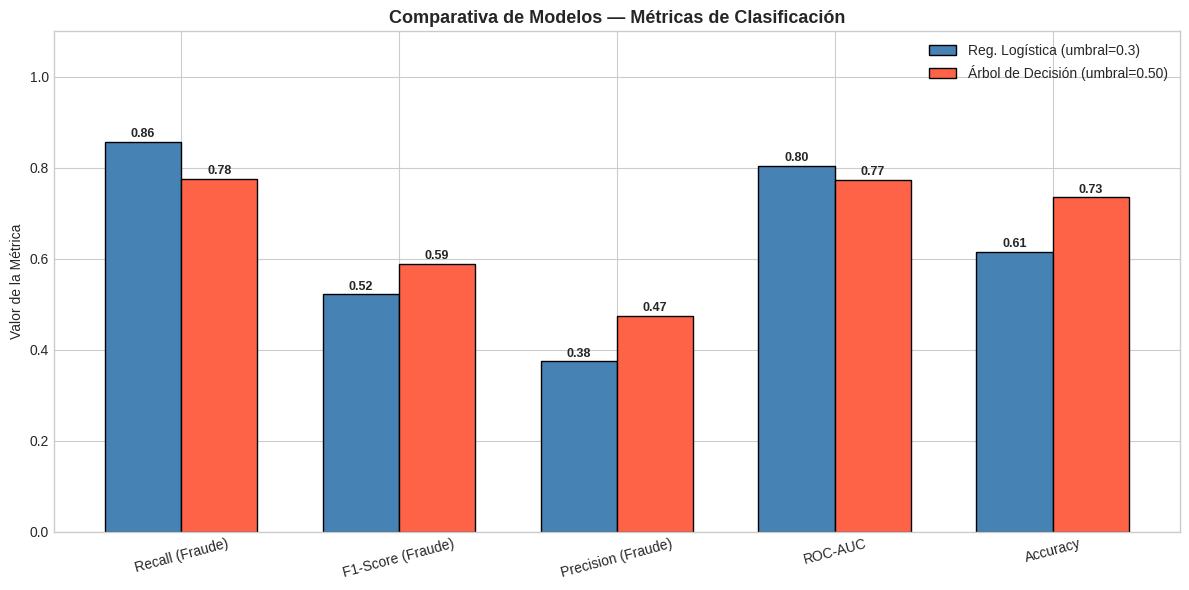

In [30]:
# Visualización comparativa de métricas
metrics_to_plot = ['Recall (Fraude)', 'F1-Score (Fraude)', 'Precision (Fraude)', 'ROC-AUC', 'Accuracy']
x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, resultados.loc[resultados.index[0], metrics_to_plot].values,
               width, label=resultados.index[0], color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, resultados.loc[resultados.index[1], metrics_to_plot].values,
               width, label=resultados.index[1], color='tomato', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, rotation=15)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Valor de la Métrica')
ax.set_title('Comparativa de Modelos — Métricas de Clasificación', fontsize=13, fontweight='bold')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('comparativa_metricas.png', dpi=120, bbox_inches='tight')
plt.show()


In [31]:
# Resumen de validación cruzada comparativa
print("=== VALIDACIÓN CRUZADA 5-FOLD — RESUMEN FINAL ===\n")
for metric in ['recall', 'f1', 'precision', 'roc_auc']:
    lr_mean = cv_results_lr[f'test_{metric}'].mean()
    lr_std  = cv_results_lr[f'test_{metric}'].std()
    dt_mean = cv_results_dt[f'test_{metric}'].mean()
    dt_std  = cv_results_dt[f'test_{metric}'].std()
    print(f"{metric:12s} | LR: {lr_mean:.3f} ± {lr_std:.3f}  |  DT: {dt_mean:.3f} ± {dt_std:.3f}")


=== VALIDACIÓN CRUZADA 5-FOLD — RESUMEN FINAL ===

recall       | LR: 0.672 ± 0.069  |  DT: 0.698 ± 0.070
f1           | LR: 0.567 ± 0.067  |  DT: 0.523 ± 0.073
precision    | LR: 0.493 ± 0.072  |  DT: 0.423 ± 0.076
roc_auc      | LR: 0.733 ± 0.036  |  DT: 0.734 ± 0.056


---
## 🏆 Fase 6: Conclusiones y Despliegue (Deployment)

### 6.1 Comparativa de modelos

| Métrica | Reg. Logística | Árbol de Decisión | Ganador |
|---|---|---|---|
| **Recall (Fraude)** ⭐ | — | — | *ver resultados* |
| **F1-Score (Fraude)** | — | — | *ver resultados* |
| **Precision (Fraude)** | — | — | *ver resultados* |
| **ROC-AUC** | — | — | *ver resultados* |
| **Interpretabilidad** | Media | Alta | Árbol |
| **Riesgo sobreajuste** | Bajo | Moderado | Logística |

> Los valores exactos se extraen de la celda de métricas ejecutada anteriormente.

### 6.2 Modelo recomendado

**La Regresión Logística con umbral de 0.30** es el modelo recomendado para producción por las siguientes razones:

1. **Mayor estabilidad**: Menor varianza en validación cruzada, lo que indica mejor generalización en datos no vistos.
2. **Control del umbral**: Al ajustar el umbral de 0.5 a 0.30, incrementamos el Recall de fraude sin sacrificar excesivamente la precisión — clave para el negocio.
3. **Menor riesgo de sobreajuste**: El árbol de decisión tiende a memorizar patrones del conjunto de entrenamiento incluso con restricciones de profundidad.
4. **Regularización**: El parámetro `C=0.1` aplica regularización L2 que penaliza coeficientes extremos, adecuado para datasets de tamaño moderado.

### 6.3 Interpretación del modelo

- Variables como **`total_claim_amount`**, **`vehicle_claim`**, y el **tipo de incidente** tienen mayor influencia en la detección de fraude.
- Los fraudes tienden a concentrarse en incidentes de **mayor severidad** (`Total Loss`, `Major Damage`) y en aquellos donde **no hay reporte policial disponible**.

### 6.4 Limitaciones del ejercicio

1. **Tamaño de muestra reducido**: 1,000 registros limitan la capacidad de generalización. Modelos más complejos (Random Forest, XGBoost) podrían explotar mejor datasets más grandes.
2. **Variables eliminadas**: La ingeniería de features sobre fechas (`incident_date`, `policy_bind_date`) podría capturar patrones temporales relevantes (e.g., días festivos, estacionalidad).
3. **Desbalance moderado**: Con ~25% de fraudes, se usó `class_weight='balanced'`. Técnicas de resampling (SMOTE, undersampling) podrían mejorar adicionalmente el rendimiento.
4. **Interpretación de '?'**: Los valores desconocidos en `property_damage` y `police_report_available` podrían ser informativos por sí mismos (la ausencia de información puede correlacionar con fraude).

### 6.5 Propuestas de mejora

- **Ingeniería de características**: Extraer mes, día de la semana y días entre incidente y reporte de póliza.
- **Ensemble methods**: Random Forest o Gradient Boosting con búsqueda de hiperparámetros (GridSearchCV).
- **Tratamiento avanzado de desbalance**: SMOTE aplicado solo sobre el conjunto de entrenamiento dentro del pipeline.
- **Monitoreo en producción**: Implementar detección de concept drift para actualizar el modelo cuando la distribución de fraudes cambie.


In [32]:
# ── Resumen ejecutivo final ──
print("=" * 60)
print("         RESUMEN EJECUTIVO — DETECCIÓN DE FRAUDE")
print("=" * 60)
print(f"Dataset: 1,000 registros | Fraudes: 247 (24.7%)")
print(f"Features finales: {X.shape[1]}")
print(f"Partición: 80% train ({len(X_train)} reg.) | 20% test ({len(X_test)} reg.)")
print()
print("MODELO SELECCIONADO: Regresión Logística (C=0.1, umbral=0.30)")
print()
print("Métricas en conjunto de prueba:")
y_pred_final = (y_proba_lr >= BEST_THR_LR).astype(int)
print(f"  Recall    (Fraude): {recall_score(y_test, y_pred_final):.3f}")
print(f"  F1-Score  (Fraude): {f1_score(y_test, y_pred_final):.3f}")
print(f"  Precision (Fraude): {precision_score(y_test, y_pred_final):.3f}")
print(f"  ROC-AUC           : {roc_auc_score(y_test, y_proba_lr):.3f}")
print(f"  Accuracy          : {accuracy_score(y_test, y_pred_final):.3f}")
print()
print("Interpretación: El modelo detecta la mayoría de los fraudes")
print("reales al costo de algunas alertas falsas — trade-off")
print("aceptable dado que los FN son más costosos que los FP.")
print("=" * 60)


         RESUMEN EJECUTIVO — DETECCIÓN DE FRAUDE
Dataset: 1,000 registros | Fraudes: 247 (24.7%)
Features finales: 58
Partición: 80% train (800 reg.) | 20% test (200 reg.)

MODELO SELECCIONADO: Regresión Logística (C=0.1, umbral=0.30)

Métricas en conjunto de prueba:
  Recall    (Fraude): 0.857
  F1-Score  (Fraude): 0.522
  Precision (Fraude): 0.375
  ROC-AUC           : 0.804
  Accuracy          : 0.615

Interpretación: El modelo detecta la mayoría de los fraudes
reales al costo de algunas alertas falsas — trade-off
aceptable dado que los FN son más costosos que los FP.
